In [2]:
import sys
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import re
import json
import lz4.frame

%load_ext autoreload
%autoreload 2
sys.path.append(os.path.abspath(".."))


# from statsmodels.stats.multitest import multipletests


In [3]:
base_dir = '/Users/cdubin/Box/VMGC_cervical_dysplasia_paper/code/'
midas_results_path = base_dir+'/cervical_dysplasia/MIDAS3/VMGC_ref/results_C90'

In [4]:
species_info = pd.read_csv(f'{base_dir}/compare_VMGC_GTDB/select_species_for_analysis/shared_species_for_analysis.csv').set_index('species')
# species_info = species_info.drop('Lactobacillus crispatus')
species_dict = species_info['species_id_VMGC'].to_dict()
species_dict

{'Lactobacillus crispatus': 988598,
 'Lactobacillus iners': 240891,
 'Bifidobacterium vaginale': 783244,
 'Fannyhessea vaginae': 619501,
 'Lactobacillus jensenii': 571325,
 'Lactobacillus gasseri': 611554}

In [5]:
metadata = pd.read_csv(f'{base_dir}/cervical_dysplasia/metadata/metadata.csv', index_col=0)
metadata = metadata[metadata['num_reads'] > 250000]
sample_list = metadata.index.tolist()

In [6]:
def decompress_tsv_lz4_to_dataframe(compressed_file):
    decompressed_file = compressed_file.replace('.lz4', '')
    try:
        with lz4.frame.open(compressed_file, 'rb') as compressed, open(decompressed_file, 'wb') as decompressed:
            decompressed.write(compressed.read())
        df = pd.read_csv(decompressed_file, sep='\t')
        os.remove(decompressed_file)
        return df
    except Exception as e:
        print(f"Error loading {compressed_file}: {e}")
        if os.path.exists(decompressed_file):
            os.remove(decompressed_file)

### Looking at sample counts after quality filtering:

In [7]:
df_dict = {}

for sp, species_id in species_dict.items():

    min_copy_num = 0.35

    #unique fraction covered
    file_path_ufc = f'{midas_results_path}/merge/species/species_unique_fraction_covered.tsv'
    unique_frac_cov = pd.read_csv(file_path_ufc, sep='\t', index_col=0)
    unique_frac_cov = unique_frac_cov.loc[species_id].to_frame(name = 'unique_fraction_covered')      

    #median marker coverage
    file_path_mmc = f'{midas_results_path}/merge/species/species_marker_median_coverage.tsv'
    marker_med_cov = pd.read_csv(file_path_mmc, sep='\t', index_col=0)
    marker_med_cov = marker_med_cov.loc[species_id].to_frame(name = 'median_marker_coverage')      

    marker_info = unique_frac_cov.merge(marker_med_cov, left_index=True, right_index=True, how='outer').reset_index(names='sample')
    marker_info = marker_info[marker_info['sample'].isin(sample_list)].set_index('sample')
        
    samples_not_found = [i for i in  sample_list if i not in marker_info.index]
    if len(samples_not_found) > 0:
        print(f'{len(samples_not_found)} samples in sample metadata file were not found in merged output files:'
            f'{samples_not_found}')

    #coverage across all genes
    to_concat = []
    for sample in marker_info.index:
        gs_path = f'{midas_results_path}/{sample}/genes/genes_summary.tsv'
        if not os.path.exists(gs_path):
            continue
        genes_summary = pd.read_csv(gs_path, sep='\t', index_col=0)
        if species_id not in genes_summary.index.tolist():
            continue

        t = genes_summary.loc[species_id][['covered_genes', 'fraction_covered','marker_depth', 'mean_depth']]
        to_concat += [t.rename(sample)]

    genome_wide_gene_profile = pd.concat(to_concat, axis=1).T

    #number of genes detected per sample
    num_genes_per_sample = {}
    for sample in marker_info.index:
        file_path = f'{midas_results_path}/{sample}/genes/{species_id}.genes.tsv.lz4'
        if not os.path.exists(file_path):
            continue
        try:
            temp = decompress_tsv_lz4_to_dataframe(file_path)
            num_genes_per_sample[sample] = temp[temp['copy_number'] >= min_copy_num].shape[0]
        except RuntimeError:
            continue

    gene_counts = pd.DataFrame.from_dict(num_genes_per_sample, orient='index')
    gene_counts.columns = ['num_genes_detected']
    df = marker_info.join(genome_wide_gene_profile, how='inner').join(gene_counts, how='inner').join(metadata, how='inner')

    df_dict[sp] = df



/var/folders/nh/_pzp_lps21jf91jy0p779fvm0000gn/T/ipykernel_21348/1512240079.py:6: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(decompressed_file, sep='\t')
/var/folders/nh/_pzp_lps21jf91jy0p779fvm0000gn/T/ipykernel_21348/1512240079.py:6: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(decompressed_file, sep='\t')


In [8]:
df_dict['Lactobacillus crispatus'].loc['VMG_0063']

unique_fraction_covered                        1.0
median_marker_coverage                      14.459
covered_genes                               9739.0
fraction_covered                             0.424
marker_depth                                14.796
mean_depth                                   5.189
num_genes_detected                            2834
Group_HC_dysplasia                              HC
Group_HC_LSIL_HSIL                Healthy controls
Group_CIN                                      NaN
Age_atSampling                                  53
Menses_yesno                                   1.0
WeeksLastMenses                                1.0
Gyn_problem_24hrs                              0.0
Gyn_Intermittentbleeding                       0.0
Gyn_Smell                                      0.0
Gyn_Itch                                       0.0
Gyn_Pain                                       0.0
Gyn_Discharge                                  0.0
Gyn_BloodyDischarge            

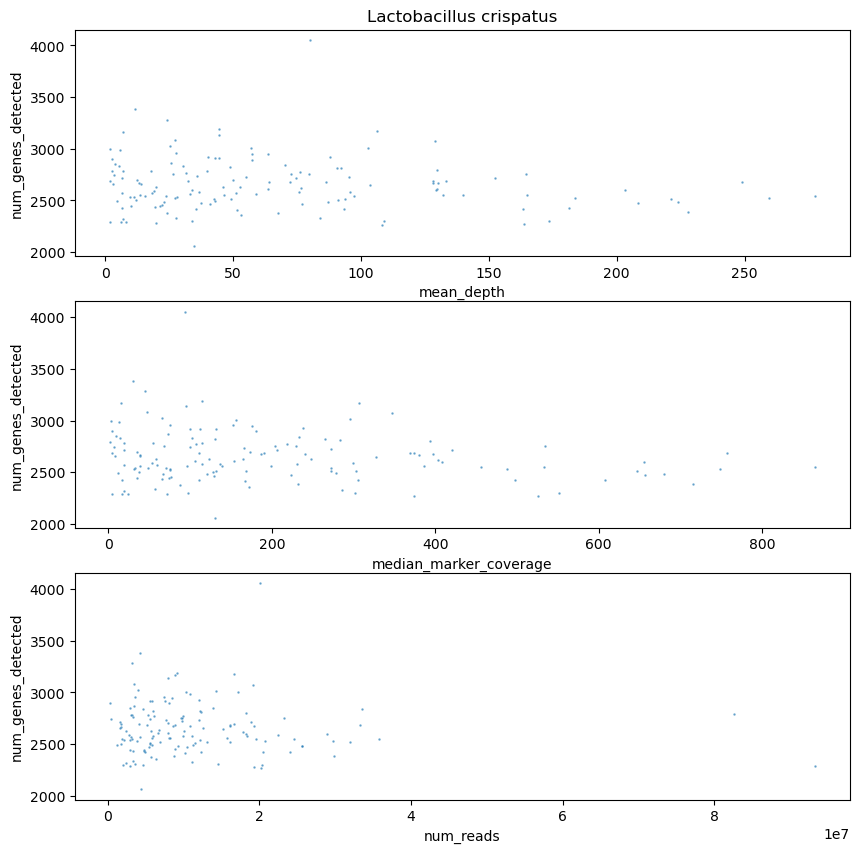

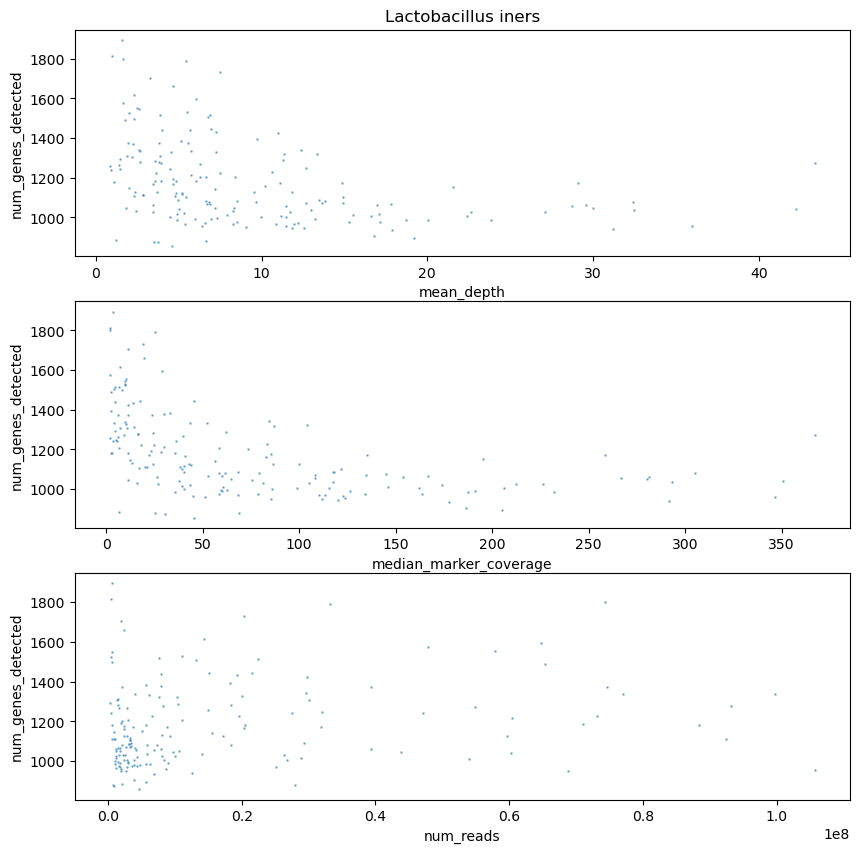

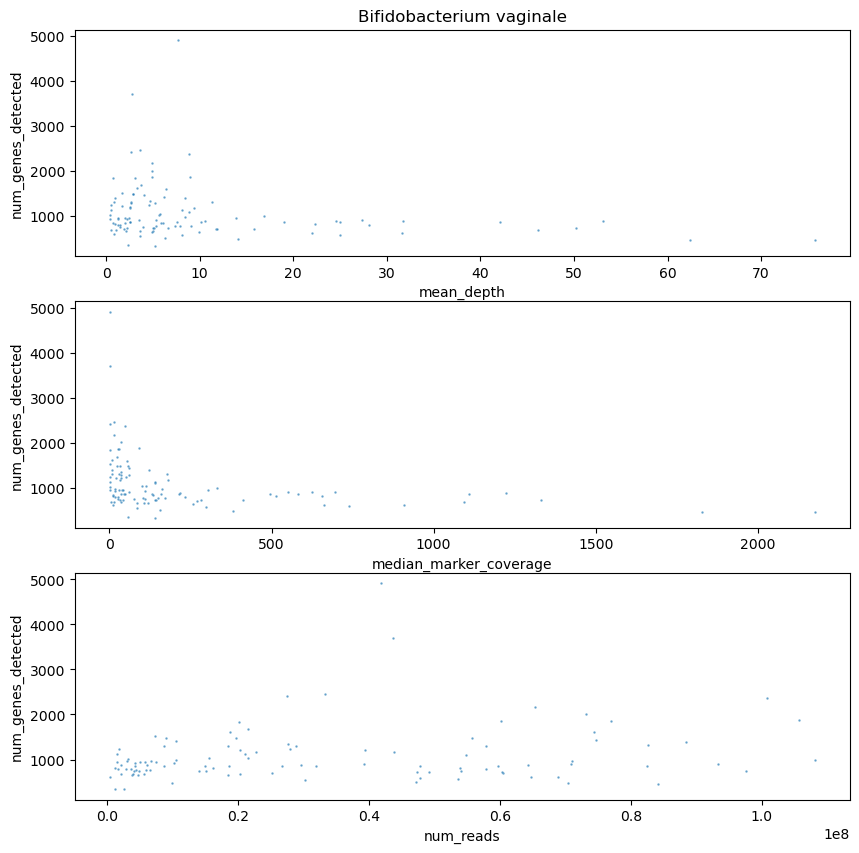

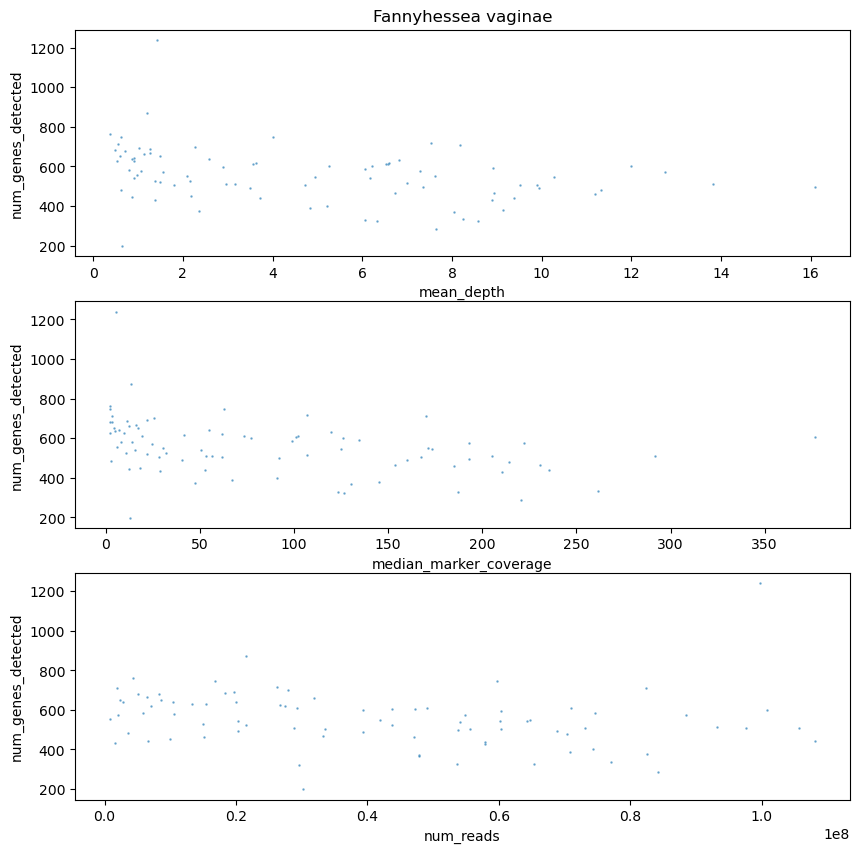

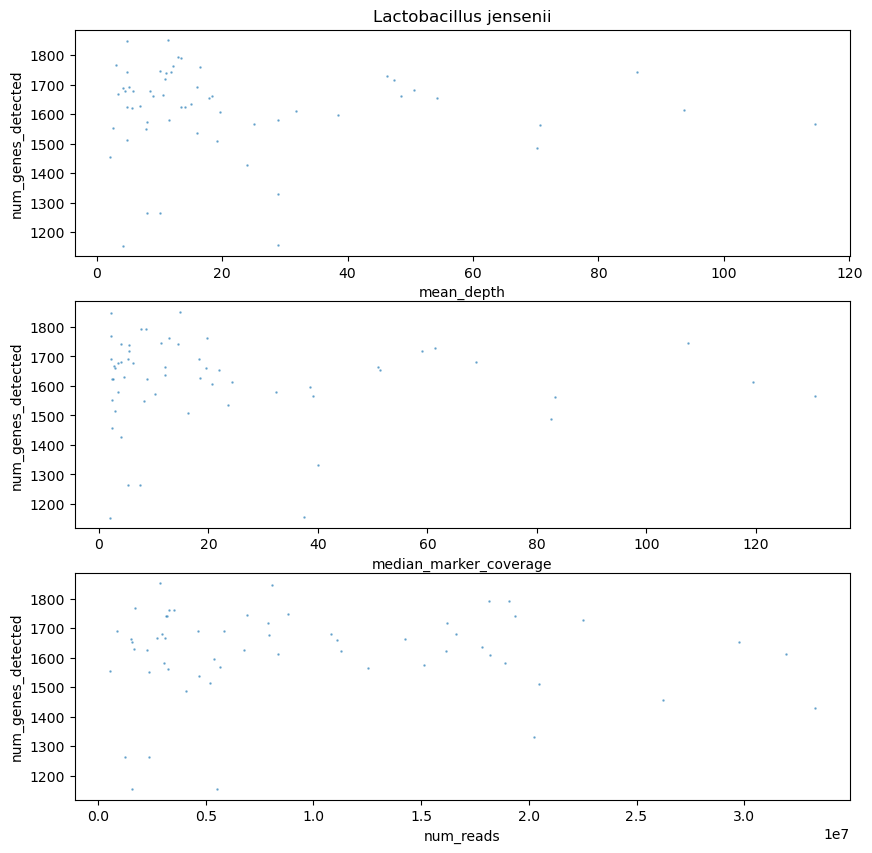

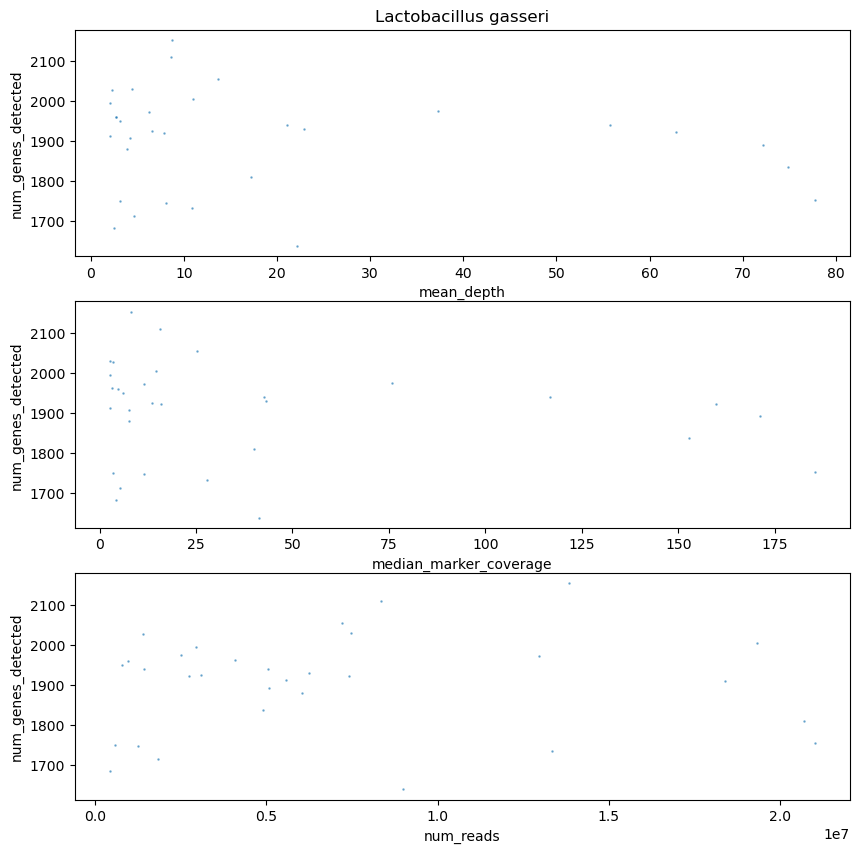

In [9]:

    
for sp, df in df_dict.items():
    fig, ax = plt.subplots(3,1, figsize=(10,10))

    sns.scatterplot(data=df, x='mean_depth', y='num_genes_detected', 
                    s=3, alpha=0.7,
                    ax=ax[0])
    # ax[0].set_xlim(0,80)
    # ax[0].axvline(3)
    ax[0].set_title(sp)


    sns.scatterplot(data=df, x='median_marker_coverage', y='num_genes_detected', 
                    s=3, alpha=0.7,
                    ax=ax[1])
    # ax[1].set_xlim(0,200)

    sns.scatterplot(data=df, x='num_reads', y='num_genes_detected', 
                    s=3, alpha=0.7,
                    ax=ax[2])


    plt.show()

In [13]:
from scipy.stats import spearmanr

thresholds_per_species = {}

for sp, df in df_dict.items():
    print(sp)
    print(spearmanr(df["mean_depth"], df["num_genes_detected"]))
    threshold = 5

    while True:

    
        sub = df[df["mean_depth"] >= threshold]
        stat, p = spearmanr(sub["mean_depth"], sub["num_genes_detected"])
        if p > 0.05:
            break
        threshold+=1

    thresholds_per_species[sp] = threshold
    print(sp, threshold, stat, p)
    print()




Lactobacillus crispatus
SignificanceResult(statistic=np.float64(-0.08182285346155532), pvalue=np.float64(0.3365150135709011))
Lactobacillus crispatus 5 -0.04094967370345049 0.6423659758471769

Lactobacillus iners
SignificanceResult(statistic=np.float64(-0.47015555305684675), pvalue=np.float64(1.6473720580622138e-10))
Lactobacillus iners 8 -0.15377094015762058 0.21409376286833623

Bifidobacterium vaginale
SignificanceResult(statistic=np.float64(-0.22606973898156504), pvalue=np.float64(0.019796325829162166))
Bifidobacterium vaginale 5 -0.23464430427893304 0.09079771231191641

Fannyhessea vaginae
SignificanceResult(statistic=np.float64(-0.4229782278183346), pvalue=np.float64(6.78332715379357e-05))
Fannyhessea vaginae 5 -0.14059628973782254 0.40654154979949575

Lactobacillus jensenii
SignificanceResult(statistic=np.float64(-0.10576020929508838), pvalue=np.float64(0.4294507852842898))
Lactobacillus jensenii 5 -0.17063228258114188 0.25149329872408055

Lactobacillus gasseri
SignificanceResult

In [14]:
for sp, df in df_dict.items():

    threshold = thresholds_per_species[sp]

    df_filt = df[df['mean_depth']>=threshold]

    print(sp, threshold)
    print(df_filt.shape)
    print(df_filt.value_counts('Group_HC_dysplasia'))
    # if "crisp" in sp:
    #     break
    print()

Lactobacillus crispatus 5
(131, 31)
Group_HC_dysplasia
HC           82
dysplasia    49
Name: count, dtype: int64

Lactobacillus iners 8
(67, 31)
Group_HC_dysplasia
dysplasia    36
HC           31
Name: count, dtype: int64

Bifidobacterium vaginale 5
(53, 31)
Group_HC_dysplasia
dysplasia    34
HC           19
Name: count, dtype: int64

Fannyhessea vaginae 5
(37, 31)
Group_HC_dysplasia
dysplasia    24
HC           13
Name: count, dtype: int64

Lactobacillus jensenii 5
(47, 31)
Group_HC_dysplasia
HC           25
dysplasia    22
Name: count, dtype: int64

Lactobacillus gasseri 5
(19, 31)
Group_HC_dysplasia
dysplasia    11
HC            8
Name: count, dtype: int64



In [15]:
thresholds_per_species

{'Lactobacillus crispatus': 5,
 'Lactobacillus iners': 8,
 'Bifidobacterium vaginale': 5,
 'Fannyhessea vaginae': 5,
 'Lactobacillus jensenii': 5,
 'Lactobacillus gasseri': 5}